#### PRE PROCESSING

##### LIBRARY

In [ ]:
import pandas as pd
import re
import seaborn as sns
from datetime import datetime, UTC

import matplotlib.pyplot as plt

import nltk
nltk.download('punkt')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer,HashingVectorizer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import  confusion_matrix, ConfusionMatrixDisplay
from sklearn.naive_bayes import MultinomialNB,ComplementNB,BernoulliNB,GaussianNB

import torch
from transformers import pipeline



#import string
#from pytz import timezone



#### OPEN DAN CEK DATA

In [ ]:
#Open data with pandas dataframe
df = pd.read_excel("./data_komentar/komentar_tiktok.xlsx")
df

#### SIMPLE CHECKING

In [ ]:
df.info()

#### CONVER TIMEZONE

In [ ]:
#change timestamp of the comment from unix timestamp to local timezone
def convert_ts_unix (df, unix_ts,new_ts) :
    df[new_ts] = df[unix_ts].apply(lambda x: datetime.fromtimestamp(int(x)))
    return df

df = convert_ts_unix(df,'date_posted_unix','date_posted')

#Take relevant column to use
# df['comment_original']= df['comment']
df = df[['comment', 'date_posted_unix','date_posted']]

#convert dateposted as string
def change_typed(df,date_posted):
    df[date_posted] = df[date_posted].astype(str)
    return df

df= change_typed(df,'date_posted')
print(df)

#### CASE FOLDING & DROP MISSING/DUPLICATE DATA

In [ ]:
#Case folding
def lowercase(df):
    df = df.str.lower()
    return df
df['case_folding'] = lowercase(df['comment'])

#Takeout missing data & duplicate in the dataframe
def clean_comment_column(df, col):
    check_missingdata = ['false', 'null', 'none', 'na', 'n/a', 'nan', 'missing', 'unknown', '']
    # Step 1: Replace placeholders with proper NA
    df[col] = df[col].replace(check_missingdata, pd.NA)
    # Step 1.1: Check data NA count   
    count_missing = df[col].isna().values.sum()
    print("total data had NA: ",count_missing)
    # Step 2: Drop rows where column is NA
    df = df.dropna(subset=[col])
    # Step 3: Drop rows where column still matches placeholders
    df = df[~df[col].isin(check_missingdata)]

    #Count duplicated data
    count_duplicate = df[col].duplicated().sum()   
    print("total data duplicate: ",count_duplicate)
    # Step 4: Drop duplicates in that column
    df = df.drop_duplicates(subset=[col])
    # Step 5: Drop any remaining NA rows in the whole DataFrame
    df = df.dropna()
    count_missing = df[col].isna().values.sum()
    print("total data had NA after drop: ",count_missing)
    #check data duplicated after processing
    count_duplicate = df[col].duplicated().sum()
    print("total data after drop duplicate: ",count_duplicate)

    return df,count_duplicate,count_missing
df,count_missing,count_duplicate = clean_comment_column(df, 'case_folding')
df

#idenya
    # check_missingdata = ['false', 'null', 'none', 'na', 'n/a', 'nan', 'missing', 'unknown', '']
    # df['comment'] = df['comment'].replace(check_missingdata, pd.NA)
    # df = df.dropna(subset=['comment'])
    # df = df[~df['comment'].isin(check_missingdata)]

    # #drop duplicated data
    # duplcicated_count = df['comment'].duplicated().sum()
    # print('total data duplicate= ', duplcicated_count)
    # df = df.drop_duplicates(subset=['comment'])

    # to make sure all missing data was dropped out

    # df = df.dropna()
    # df.info()

### CLEANING 2

In [ ]:
# comment #2
# Erase URL
def remove_URL(text):      
		url = re.compile(r'https?://\S+|www\.\S+').sub(r'',text)         
		return url
df['clean_text'] = df['case_folding'].apply(lambda x: remove_URL(x))

# Erase Html
def remove_html(comment):        
		html = re.compile(r'<.*?>').sub(r'',comment)
		return html
df['clean_text'] = df['clean_text'].apply(lambda x: remove_html(x))

# Erase Emoji
def remove_emoji(comment):
    emoji_pattern = re.compile("["             
			u"\U0001F600-\U0001F64F"  #emoticons             
			u"\U0001F300-\U0001F5FF"  #symbols & pictographs 
			u"[\U0001FA00-\U0001FA6F"  #Chess Symbols
			u"\U0001FA70-\U0001FAFF"   #Symbols and Pictographs Extended-A
			u"\U0001F004-\U0001F0CF"   #Additional emoticons
			u"\U0001F1E0-\U0001F1FF"   #Flags
            u"\U0001F680-\U0001F6FF"  #transport & map symbols
            u"\U00002700-\U000027BF"  #dingbats
            "]+",
            flags=re.UNICODE
            )
    cleaned = emoji_pattern.sub(r'',comment)
    return cleaned
df['clean_text'] = df['clean_text'].apply(lambda x: remove_emoji(x))

# Erase Symbol
def remove_symbols(comment):
    cleaned = re.sub(r'[^a-zA-Z0-9\s]', '', comment)
    return cleaned
df['clean_text'] = df['clean_text'].apply(lambda x: remove_symbols(x))

# Erase Number
def remove_numbers(comment):
    # if comment is not None and isinstance(comment, str):
    cleaned = re.sub(r'\d', '', comment)
    return cleaned

df['clean_text'] = df['clean_text'].apply(lambda x: remove_numbers(x))

# Erase Username
def remove_usernames(text):
    cleaned = re.sub(r'@\w+', '', text)
    return cleaned
df['clean_text'] = df['clean_text'].apply(lambda x: remove_usernames(x))

df

### SIMPLE ANALYSE ANOMALY DATA

In [ ]:
print("shape data")
print(df.shape)
print("\n")
print("kolom yg ada")
print(df.columns)
print("\n")
print("Check missing values")
print(df.dtypes)
print(df.isna().sum())
print("\n")
print("Samples")
df.sample(10)

In [ ]:
print("Describe")
df.describe(include='all')
df

In [ ]:
# the idea
    # Takeout missing relevant data in the dataframe AGAIN, to make sure there isnt a missing values in dataframe, 
    # because sometimes there is a comment only an icon/emoji that cleaned after first cleaned that not included a emoji eraser
    # as you can see there is top value as blank spaces repeated 108 times there.

#clean data clean text
df,count_duplicate,count_missing= clean_comment_column(df, 'clean_text')

print("Describe")
df.describe(include='all')

#### Normalisasi Bahasa Indonesia

In [ ]:
# Download kamus kata tidak baku dari  : https://github.com/analysisdatasentiment/kamus_kata_baku/ra
    #w/main/kamuskatabaku.xlsx
path_bow =('kamuskatabaku.xlsx')
bag_of_word_bahasa = pd.read_excel(path_bow)

# Formal Word
def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()

        replaced_words = []             # kalimat yg di normalisasi
        kata_baku = []                  # kata tidak baku yg diganti dalam kalimat
        kata_tidak_baku = []            # kata tidak baku dalam kalimat
        kata_tidak_baku_hash = []       # has words

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]
                if isinstance(baku_word, str) and all(char.isalpha() for char in baku_word):
                    replaced_words.append(baku_word)
                    kata_baku.append(baku_word)
                    kata_tidak_baku.append(word)
                    kata_tidak_baku_hash.append(hash(word))
            else:
                replaced_words.append(word)

        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ''
        kata_baku = []
        kata_tidak_baku = []
        kata_tidak_baku_hash = []

    return replaced_text, kata_baku, kata_tidak_baku, kata_tidak_baku_hash

# Buat dictionary dari kamus 
kamus_tidak_baku_dict = dict(zip(bag_of_word_bahasa['tidak_baku'], 
bag_of_word_bahasa['kata_baku'])) 

# Terapkan fungsi normalisasi 
df[['normalisasi', 'Kata_Baku', 'Kata_Tidak_Baku', 
'Kata_Tidak_Baku_Hash']] = df['clean_text'].apply( 
    lambda x: pd.Series(replace_taboo_words(x, 
kamus_tidak_baku_dict)) 
)

df


#### CHECKING THE DATA AGAIN 

In [ ]:
# # show duplicate data
# data = df[df.duplicated(subset=['normalisasi'], keep=False)]
# data

#clean data clean text
df,count_duplicate,count_missing= clean_comment_column(df, 'normalisasi')

print("Describe")
df.describe(include='all')

### REMOVE STOPWORD


In [ ]:
import Sastrawi
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory, StopWordRemover, ArrayDictionary

more_stop_words = []

stop_words = StopWordRemoverFactory().get_stop_words()
stop_words.extend(more_stop_words)

new_array = ArrayDictionary(stop_words)
stop_words_remover_new = StopWordRemover(new_array)

def stopword(str_text):
    str_text = stop_words_remover_new.remove(str_text)
    return str_text

df['stopword'] = df['normalisasi'].apply(lambda x : stopword(x))
df = df[['normalisasi', 'stopword']]
df


In [ ]:
#clean data clean text

df,count_duplicate,count_missing= clean_comment_column(df, 'stopword')

print("Describe")
df.describe(include='all')

### TOKENISASI

In [ ]:
#tokenize
df["tokenized"] = df['stopword'].apply(lambda x:x.split())
df["tokenized"].head()


### STEMMING

In [15]:
#STEMMING
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

def stem(text_bersih):
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
    do = []
    for w in text_bersih:
        dt = stemmer.stem(w)
        do.append(dt)
    d_clean = []
    d_clean = ' '.join(do)
    print(d_clean)
    return d_clean

df['clean_text'] = df["tokenized"].apply(stem)




moga semuaa baik ajaaaaa
kalau perintah punya hati sumbang natal negeri luar batalin mending di kasih daerah sumatra
astafiraullah
ai bang
wahai perintah mana bantu
semua tambang emas tambang pohon lahan lahan sawit hujan bisa serap banyak pohon bagai spesies
akhir tahun banyak bencana
sudah bencana skala nasional moga lekas pulih
allah lindung saudara semua ada disna moga tiada korban jiwa amin rabbal alamin
bencana nasional nih
merinding aku tau arti yang hilang anak arti cari dulu anak perempuan ku
kota padangsidimpuan bukan kabupaten
yaallah gusti
biasa kalau bencanatni ikit turun bantuapa ada perintah perintah tempat
perintah pusat tutup mata gilir bangsa timur tengah sana respon kalah flashhh
kayak begini perintah
moga saudara yang alami bencana sana moga tuhan jaga raka semuaagar tetap selamat tetap aman tetap jaga selalu lindung tuhan selalu ikan sehat amain
gubernur mantu jokowi saja lo
allah ampun dan selamat kan sanak saudara ku sana
moga cepat pulih
sd sudah ajar kalau gund

### SAVED to excel

In [16]:
# # show duplicate data
# data = df[df.duplicated(subset=['clean_text'], keep=False)]
# data

df

#save data ke dataframe
df = pd.DataFrame(df)
df = df[['clean_text']]
# # convert ke excel xlsxa
df.to_csv('./hasil_stemming.csv', index=False)
# df.sample(10)

In [17]:
# #isi stopword sastrawi
# from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
# stop_factory = StopWordRemoverFactory()
# more_stopword1 = []
# data = stop_factory.get_stop_words()+more_stopword1
# stopword = stop_factory.create_stop_word_remover()
# print(data)

### SAVE TO EXCEL

In [18]:
# #save data ke dataframe
# df = pd.DataFrame(df)
# # convert ke excel xlsxa
# df.to_excel('hasil_prepro.xlsx', index=False)

### LABELING

In [19]:
df = pd.read_csv("./hasil_stemming.csv")
df.head()

,clean_text
0,mungkin ingat allah atas jadi masjid agung sib...
1,makanya warga asli papua sangat tentang progra...
2,allah lindung saudarasaudari semua
3,pray for sumatera
4,punya duit yang tebang phon sembarang nikmat d...


In [20]:
# classifier
classifier = pipeline("sentiment-analysis", model="w11wo/indonesian-roberta-base-sentiment-classifier")

#fungsi sentimen
def prediksi_sentimen(teks):
    hasil = classifier(teks)
    return hasil[0]['label']

df['sentimen'] = df['clean_text'].apply(prediksi_sentimen)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1181.09it/s]
RobertaForSequenceClassification LOAD REPORT from: w11wo/indonesian-roberta-base-sentiment-classifier
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [21]:
sentimen = df['sentimen'].value_counts()
sentimen


sentimen
negative    562
neutral     273
positive    254
Name: count, dtype: int64

In [22]:
df
# # convert ke excel xlsxa
df.to_csv('../3_labeling/hasil_labeling.csv', index=False)

In [23]:
df

,clean_text,sentimen
0,mungkin ingat allah atas jadi masjid agung sib...,neutral
1,makanya warga asli papua sangat tentang progra...,negative
2,allah lindung saudarasaudari semua,neutral
3,pray for sumatera,neutral
4,punya duit yang tebang phon sembarang nikmat d...,negative
...,...,...
1084,bobby tanggung jawab kau,negative
1085,halo kakak semua sedang scroll tiktok ngemil p...,neutral
1086,partai solidaritas indonesia gibran rakabuming...,neutral
1087,yuhuuu semangat gubernur kuuuuuu,positive


### VISUALIZE

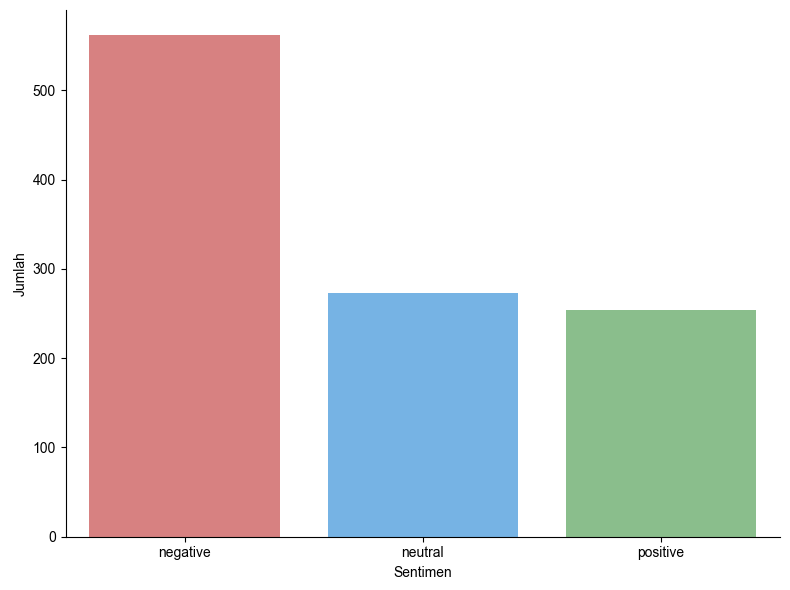

In [24]:

plt.figure(figsize=(8,6))
sns.countplot(x='sentimen', data=df,
                order=['negative', 'neutral', 'positive'], #posisi label kiri -> kanan
                hue = 'sentimen',
                legend = False,
                palette={
                        'negative': '#E57373',  # soft red
                        'neutral': '#64B5F6',   # soft blue
                        'positive': '#81C784'   # soft green
                        }
    )

plt.title = "Distribusi Sentimen"
plt.xlabel("Sentimen")
plt.ylabel("Jumlah")

sns.despine()  # remove top/right border biar clean
plt.tight_layout()

sns.set_style("whitegrid")
sns.set_context("talk", font_scale=0.8)

plt.show()

### TRAINING DATA

In [25]:
X=df.clean_text
y=df.sentimen

#define test and train data
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#divide 20% of it as test data

# Hitung bobot kata 
cvec=CountVectorizer()
tvec=TfidfVectorizer(binary=True, max_df=0.85, min_df=2, ngram_range=(1,1))
hvec=HashingVectorizer()


#### Naive Bayes    

In [26]:
clf_nb = MultinomialNB()

model_nb =   Pipeline([('vectorizer', tvec),('classifier', clf_nb)])

model_nb = model_nb.fit(x_train,y_train)

# visualisasi
hasil_nb = model_nb.predict(x_test)

<>:7: SyntaxWarning: invalid escape sequence '\H'
<>:23: SyntaxWarning: invalid escape sequence '\H'
<>:7: SyntaxWarning: invalid escape sequence '\H'
<>:23: SyntaxWarning: invalid escape sequence '\H'
C:\Users\marta\AppData\Local\Temp\ipykernel_18996\3487891641.py:7: SyntaxWarning: invalid escape sequence '\H'
  plt.savefig('..\Hasil_CM\confusion_matrix.png', dpi=300, bbox_inches='tight')
C:\Users\marta\AppData\Local\Temp\ipykernel_18996\3487891641.py:23: SyntaxWarning: invalid escape sequence '\H'
  df_report.to_csv('..\HASIL_CM\classification_report.csv', index=True)


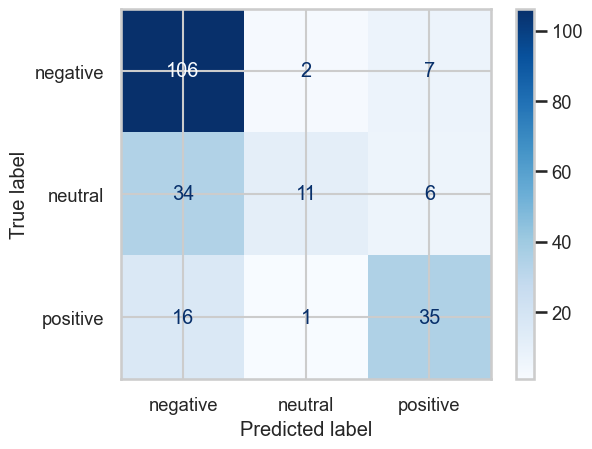

Classisfication Report: 
               precision    recall  f1-score   support

    negative       0.68      0.92      0.78       115
     neutral       0.79      0.22      0.34        51
    positive       0.73      0.67      0.70        52

    accuracy                           0.70       218
   macro avg       0.73      0.60      0.61       218
weighted avg       0.72      0.70      0.66       218

Classification Report sukses disimpan sebagai CSV di dalam sub-folder!


In [ ]:
# confusion matrix
cm = confusion_matrix(y_test,hasil_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model_nb.classes_)
disp.plot(cmap='Blues')
plt.title=('Confusion Matrix NB')
#Simpan CM
plt.savefig('..\Hasil_CM\confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# report classification
matrix = classification_report(y_test,hasil_nb)
print('Classisfication Report: \n', matrix)


# 1. Ambil report dalam bentuk dictionary
matrix_dict = classification_report(y_test, hasil_nb, output_dict=True)

# 2. Ubah jadi DataFrame dan langsung transpose agar rapi
df_report = pd.DataFrame(matrix_dict).transpose()

# 3. Simpan ke sub-folder 'hasil' dengan format CSV
# Cukup tulis: 'nama_folder/nama_file.csv'
df_report.to_csv('..\HASIL_CM\classification_report.csv', index=True)

print("Classification Saved!")

